In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    GridSearchCV
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin, clone

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    precision_score,
    recall_score
)

from catboost import CatBoostClassifier


In [2]:
train = pd.read_csv("/kaggle/input/competitions/titanic/train.csv")
test = pd.read_csv("/kaggle/input/competitions/titanic/test.csv")

print(train.head())
print(train.info())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
<c

In [3]:
target = "Survived"

drop_cols = ["PassengerId", "Name", "Ticket", "Cabin"]

X = train.drop(columns=[target] + drop_cols)
y = train[target]

X_test = test.drop(columns=drop_cols)

print(X.dtypes)

Pclass        int64
Sex          object
Age         float64
SibSp         int64
Parch         int64
Fare        float64
Embarked     object
dtype: object


In [4]:
numeric = X.select_dtypes(include=np.number).columns.tolist()
categorical = X.select_dtypes(exclude=np.number).columns.tolist()

print("Numeric:", numeric)
print("Categorical:", categorical)

Numeric: ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
Categorical: ['Sex', 'Embarked']


In [5]:
print(X.isna().sum())

Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64


In [6]:
numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipe, numeric),
    ("cat", categorical_pipe, categorical)
])

Для подбора параметров понадобится также валидация

In [7]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(X_train.shape)
print(X_val.shape)

(712, 7)
(179, 7)


Начнем с дерева. Надо подобрать глубину. Для начала определим максимальную:

In [8]:
tree_full = Pipeline([
    ("prep", preprocessor),
    ("model", DecisionTreeClassifier(random_state=42))
])

tree_full.fit(X_train, y_train)

full_depth = tree_full.named_steps["model"].tree_.max_depth

print("Максимальная глубина полного дерева:", full_depth)

Максимальная глубина полного дерева: 23


In [9]:
depths = range(1, full_depth + 1)

train_f1 = []
val_f1 = []

for depth in depths:
    model = Pipeline([
        ("prep", preprocessor),
        ("model", DecisionTreeClassifier(
            max_depth=depth,
            random_state=42
        ))
    ])

    model.fit(X_train, y_train)

    train_f1.append(
        f1_score(y_train, model.predict(X_train))
    )

    val_f1.append(
        f1_score(y_val, model.predict(X_val))
    )

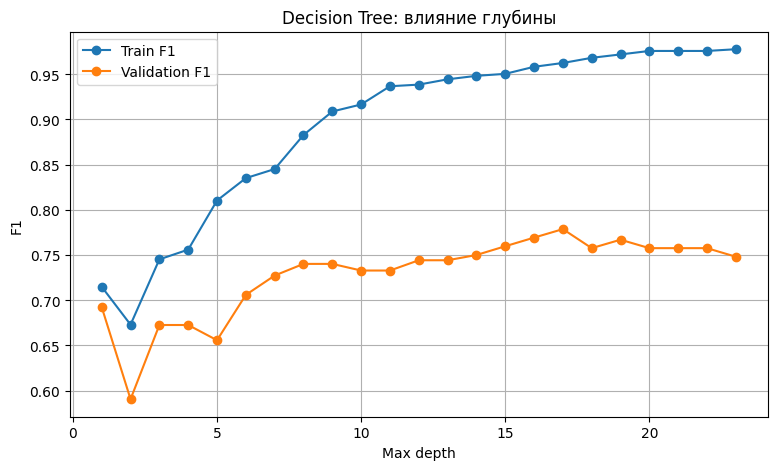

In [10]:
plt.figure(figsize=(9, 5))

plt.plot(depths, train_f1, marker="o", label="Train F1")
plt.plot(depths, val_f1, marker="o", label="Validation F1")

plt.xlabel("Max depth")
plt.ylabel("F1")
plt.title("Decision Tree: влияние глубины")
plt.legend()
plt.grid()
plt.show()

Видно, что на трене F1 продолжает стабильно возрастать, а вот на валидации он в какой-то момент выходит на плато. Модель переобучается.Посмотрим, что будет, если добавить кросс-валидацию для стабильности.

In [11]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

depth_cv = []

for depth in depths:
    model = Pipeline([
        ("prep", preprocessor),
        ("model", DecisionTreeClassifier(
            max_depth=depth,
            random_state=42
        ))
    ])

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="f1"
    )

    depth_cv.append(scores.mean())

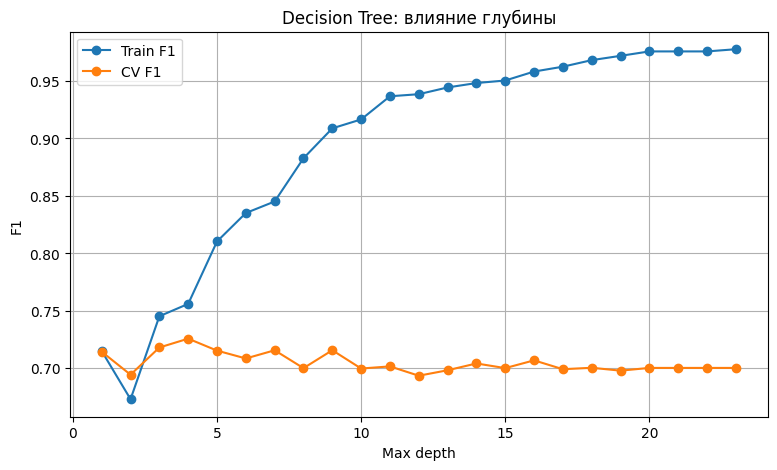

In [12]:
train_cv = []

for depth in depths:
    model = Pipeline([
        ("prep", preprocessor),
        ("model", DecisionTreeClassifier(
            max_depth=depth,
            random_state=42
        ))
    ])

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="f1"
    )

    model.fit(X_train, y_train)

    train_cv.append(
        f1_score(y_train, model.predict(X_train))
    )

plt.figure(figsize=(9, 5))

plt.plot(depths, train_cv, marker="o", label="Train F1")
plt.plot(depths, depth_cv, marker="o", label="CV F1")

plt.xlabel("Max depth")
plt.ylabel("F1")
plt.title("Decision Tree: влияние глубины")
plt.legend()
plt.grid()
plt.show()

Переобучение еще заметнее.

In [13]:
best_depth = depths[np.argmax(depth_cv)]

print("Best max_depth:", best_depth)
print("Best CV F1:", max(depth_cv))

Best max_depth: 4
Best CV F1: 0.7256673010073162


Определим диапазон.

In [14]:
n = len(X_train)

leaf_max = max(1, int(np.sqrt(n)))
split_max = max(2, int(np.sqrt(n)))

leaf_values = range(1, leaf_max + 1)
split_values = range(2, split_max + 1)

print("min_samples_leaf:", list(leaf_values))
print("min_samples_split:", list(split_values))

min_samples_leaf: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26]
min_samples_split: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26]


Т.к. данные небольшие, можно позволить себе снова перебор.

In [15]:
leaf_scores = []

for leaf in leaf_values:
    model = Pipeline([
        ("prep", preprocessor),
        ("model", DecisionTreeClassifier(
            max_depth=best_depth,
            min_samples_leaf=leaf,
            random_state=42
        ))
    ])

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="f1"
    )

    leaf_scores.append(scores.mean())

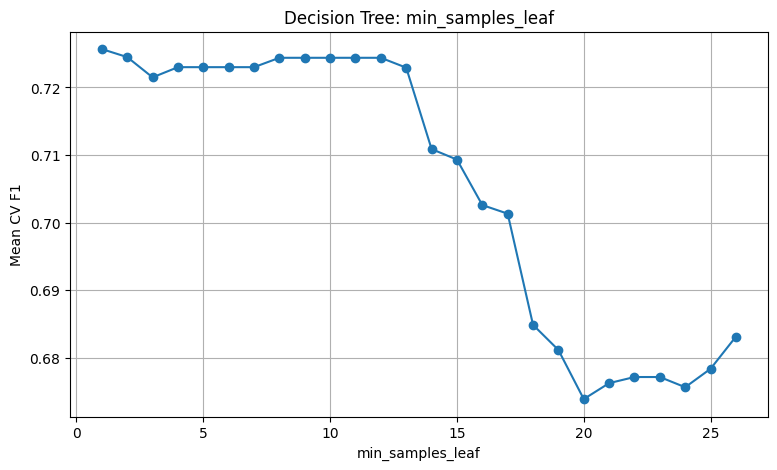

In [16]:
plt.figure(figsize=(9, 5))

plt.plot(list(leaf_values), leaf_scores, marker="o")

plt.xlabel("min_samples_leaf")
plt.ylabel("Mean CV F1")
plt.title("Decision Tree: min_samples_leaf")
plt.grid()
plt.show()

In [17]:
best_leaf = list(leaf_values)[np.argmax(leaf_scores)]

print("Best min_samples_leaf:", best_leaf)

Best min_samples_leaf: 1


In [18]:
split_scores = []

for split in split_values:
    model = Pipeline([
        ("prep", preprocessor),
        ("model", DecisionTreeClassifier(
            max_depth=best_depth,
            min_samples_leaf=best_leaf,
            min_samples_split=split,
            random_state=42
        ))
    ])

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="f1"
    )

    split_scores.append(scores.mean())

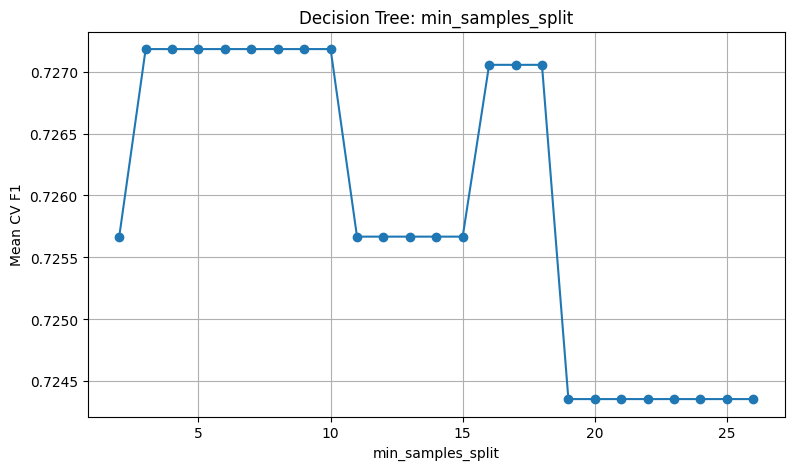

In [19]:
plt.figure(figsize=(9, 5))

plt.plot(list(split_values), split_scores, marker="o")

plt.xlabel("min_samples_split")
plt.ylabel("Mean CV F1")
plt.title("Decision Tree: min_samples_split")
plt.grid()
plt.show()

Разница - после второго знака. Ну т.е. ее нет. Пусть будет 5.

In [20]:
best_split = 5

Переходим к лесу. Для начала определим, сколько нужно деревьев.

In [21]:
tree = Pipeline([
    ("prep", preprocessor),
    ("model", DecisionTreeClassifier(
        max_depth=best_depth,
        min_samples_leaf=best_leaf,
        min_samples_split=best_split,
        random_state=42
    ))
])

tree.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Pclass', 'Age', 'SibSp',
                                                   'Parch', 'Fare']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Sex', 'Embarked'])])),
                ('model',
                 DecisionTreeClassifier(max_depth=4, min_samples_split=5,
                                        random_state=42))])

In [22]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=1,
        warm_start=True,
        bootstrap=True,
        random_state=42,
        n_jobs=-1
    ))
])

# Создаём отдельную модель для каждого CV-fold,
# чтобы warm_start сохранял деревья внутри каждого fold
fold_models = []

for train_idx, val_idx in cv.split(X_train, y_train):
    fold_models.append({
        "model": clone(rf_pipeline),
        "X_train": X_train.iloc[train_idx],
        "X_val": X_train.iloc[val_idx],
        "y_train": y_train.iloc[train_idx],
        "y_val": y_train.iloc[val_idx]
    })


n_estimators_values = []
cv_scores = []

best_score = -np.inf
best_n = None
no_improvement = 0

for n_estimators in range(1, len(X_train) + 1):

    fold_scores = []

    for fold in fold_models:

        model = fold["model"]

        model.named_steps["model"].set_params(
            n_estimators=n_estimators
        )

        model.fit(
            fold["X_train"],
            fold["y_train"]
        )

        pred = model.predict(fold["X_val"])

        fold_scores.append(
            f1_score(fold["y_val"], pred)
        )

    mean_score = np.mean(fold_scores)

    n_estimators_values.append(n_estimators)
    cv_scores.append(mean_score)

    if mean_score > best_score:
        best_score = mean_score
        best_n = n_estimators
        no_improvement = 0
    else:
        no_improvement += 1

    # Останавливаемся, если 5 последовательных
    # добавлений деревьев не улучшили CV F1
    if no_improvement >= 5:
        break

print(f"Best n_estimators: {best_n}")
print(f"Best CV F1: {best_score:.4f}")

Best n_estimators: 13
Best CV F1: 0.7297


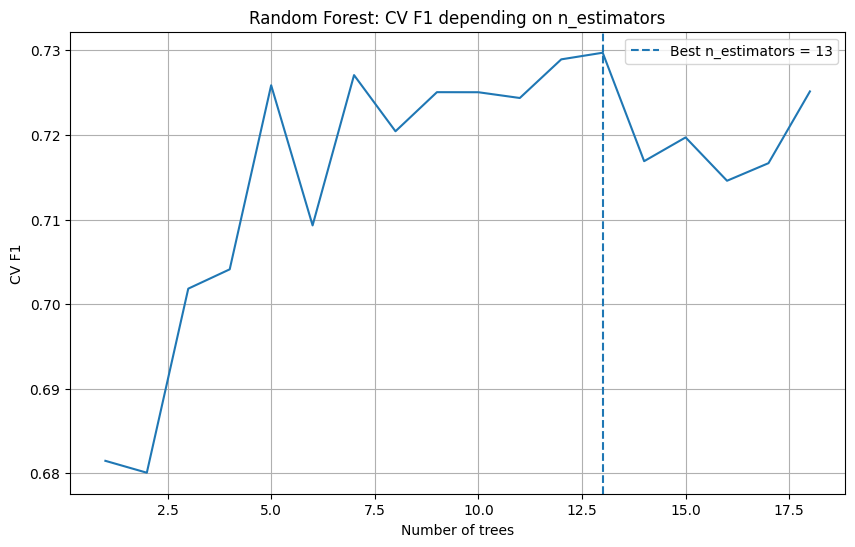

Best n_estimators: 13
Best CV F1: 0.7297


In [23]:
# График
plt.figure(figsize=(10, 6))
plt.plot(n_estimators_values, cv_scores)
plt.axvline(
    best_n,
    linestyle="--",
    label=f"Best n_estimators = {best_n}"
)
plt.xlabel("Number of trees")
plt.ylabel("CV F1")
plt.title("Random Forest: CV F1 depending on n_estimators")
plt.legend()
plt.grid()
plt.show()

print(f"Best n_estimators: {best_n}")
print(f"Best CV F1: {best_score:.4f}")

In [24]:
# Финальная модель с найденным количеством деревьев
rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=best_n,
        bootstrap=True,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_val)

print(f"Validation F1: {f1_score(y_val, rf_pred):.4f}")

Validation F1: 0.7576


Теперь остался только CatBoost. Там тоже надо подобрать глубину, и желательно не сильно тупо, а то будет 20 минут вычислять. Поэтому здесь я беру сетку параметров с фиксированными значениями.

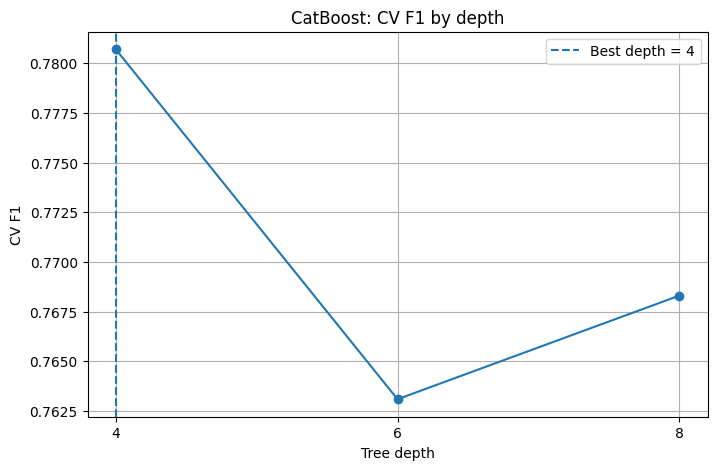

Best depth: 4
Best CV F1: 0.7807


CatBoostClassifier(allow_writing_files=False, depth=4, devices='0', iterations=300, learning_rate=0.1, random_seed=42, task_type='GPU', verbose=False)

In [25]:
categorical_cb = X_train.select_dtypes(
    exclude=np.number
).columns.tolist()

depth_values = [4, 6, 8]

cv_scores = []
best_score = -np.inf
best_depth = None

for depth in depth_values:

    fold_scores = []

    for train_idx, val_idx in cv.split(X_train, y_train):

        X_fold_train = X_train.iloc[train_idx].copy()
        X_fold_val = X_train.iloc[val_idx].copy()

        y_fold_train = y_train.iloc[train_idx]
        y_fold_val = y_train.iloc[val_idx]

        # Заполняем категориальные признаки
        for col in categorical_cb:
            X_fold_train[col] = (
                X_fold_train[col]
                .fillna("Missing")
                .astype(str)
            )

            X_fold_val[col] = (
                X_fold_val[col]
                .fillna("Missing")
                .astype(str)
            )

        model = CatBoostClassifier(
            depth=depth,
            iterations=300,
            learning_rate=0.1,
            verbose=False,
            random_seed=42,
            task_type="GPU",
            devices="0",
            allow_writing_files=False
        )

        model.fit(
            X_fold_train,
            y_fold_train,
            cat_features=categorical_cb
        )

        proba = model.predict_proba(X_fold_val)[:, 1]

        # Подбор порога внутри fold
        thresholds = np.unique(proba)

        fold_f1 = max(
            f1_score(
                y_fold_val,
                (proba >= threshold).astype(int)
            )
            for threshold in thresholds
        )

        fold_scores.append(fold_f1)

    mean_score = np.mean(fold_scores)
    cv_scores.append(mean_score)

    if mean_score > best_score:
        best_score = mean_score
        best_depth = depth

# Результаты подбора depth

plt.figure(figsize=(8, 5))

plt.plot(
    depth_values,
    cv_scores,
    marker="o"
)

plt.axvline(
    best_depth,
    linestyle="--",
    label=f"Best depth = {best_depth}"
)

plt.xlabel("Tree depth")
plt.ylabel("CV F1")
plt.title("CatBoost: CV F1 by depth")
plt.xticks(depth_values)
plt.legend()
plt.grid()

plt.show()

print(f"Best depth: {best_depth}")
print(f"Best CV F1: {best_score:.4f}")

# Финальная модель

X_train_cb = X_train.copy()

for col in categorical_cb:
    X_train_cb[col] = (
        X_train_cb[col]
        .fillna("Missing")
        .astype(str)
    )

cat_model = CatBoostClassifier(
    depth=best_depth,
    iterations=300,
    learning_rate=0.1,
    verbose=False,
    random_seed=42,
    task_type="GPU",
    devices="0",
    allow_writing_files=False
)

cat_model.fit(
    X_train_cb,
    y_train,
    cat_features=categorical_cb
)

Теперь нужно сравнить все модели. При этом прежде, чем сравнивать, нужно подобрать порог.

=== СРАВНЕНИЕ МОДЕЛЕЙ ===
        Model  Threshold     F1
Decision Tree     0.4074 0.7067
Random Forest     0.5256 0.7576
     CatBoost     0.5988 0.7619


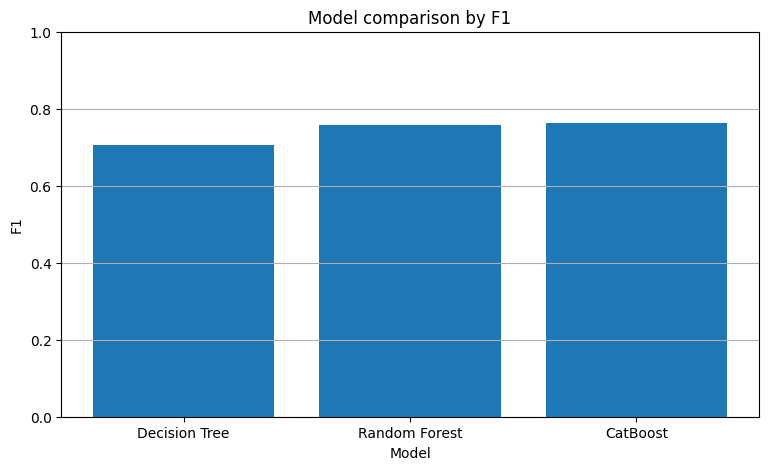

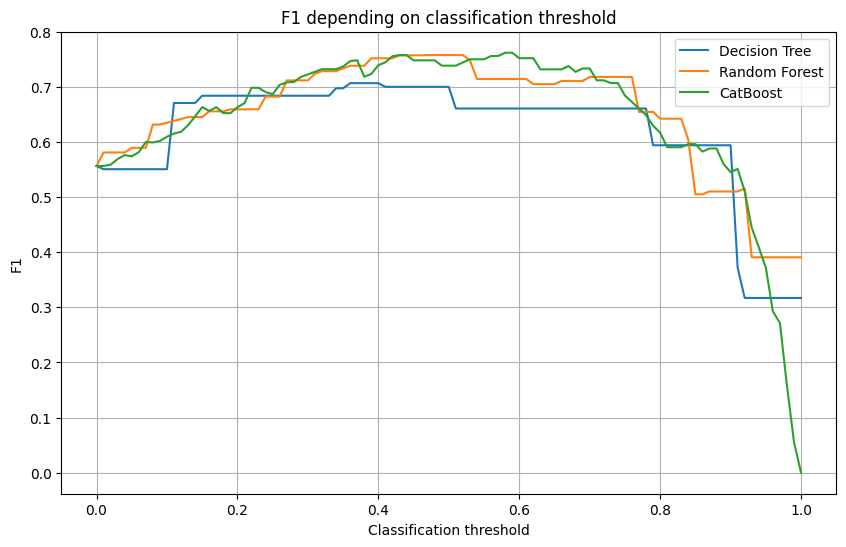

In [26]:
models = {
    "Decision Tree": tree,
    "Random Forest": rf_model,
    "CatBoost": cat_model
}


# =========================
# Подбор оптимального порога
# =========================

def find_best_threshold(y_true, probabilities):
    thresholds = np.unique(probabilities)

    scores = [
        f1_score(
            y_true,
            (probabilities >= threshold).astype(int)
        )
        for threshold in thresholds
    ]

    best_idx = np.argmax(scores)

    return thresholds[best_idx], scores[best_idx]


results = []

for name, model in models.items():

    # CatBoost работает с исходными категориальными признаками
    if name == "CatBoost":
        X_eval = X_val.copy()

        for col in categorical_cb:
            X_eval[col] = (
                X_eval[col]
                .fillna("Missing")
                .astype(str)
            )

        probabilities = model.predict_proba(X_eval)[:, 1]

    else:
        probabilities = model.predict_proba(X_val)[:, 1]

    threshold, f1 = find_best_threshold(
        y_val,
        probabilities
    )

    results.append({
        "Model": name,
        "Threshold": threshold,
        "F1": f1
    })


# =========================
# Таблица
# =========================

results_df = pd.DataFrame(results)

print("=== СРАВНЕНИЕ МОДЕЛЕЙ ===")
print(
    results_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# =========================
# График F1
# =========================

plt.figure(figsize=(9, 5))

plt.bar(
    results_df["Model"],
    results_df["F1"]
)

plt.ylabel("F1")
plt.xlabel("Model")
plt.title("Model comparison by F1")
plt.ylim(0, 1)
plt.grid(axis="y")

plt.show()


# =========================
# F1 от порога
# =========================

plt.figure(figsize=(10, 6))

for name, model in models.items():

    if name == "CatBoost":
        X_eval = X_val.copy()

        for col in categorical_cb:
            X_eval[col] = (
                X_eval[col]
                .fillna("Missing")
                .astype(str)
            )

        probabilities = model.predict_proba(X_eval)[:, 1]

    else:
        probabilities = model.predict_proba(X_val)[:, 1]

    thresholds = np.linspace(0, 1, 101)

    scores = [
        f1_score(
            y_val,
            (probabilities >= threshold).astype(int)
        )
        for threshold in thresholds
    ]

    plt.plot(
        thresholds,
        scores,
        label=name
    )

plt.xlabel("Classification threshold")
plt.ylabel("F1")
plt.title("F1 depending on classification threshold")
plt.legend()
plt.grid()

plt.show()

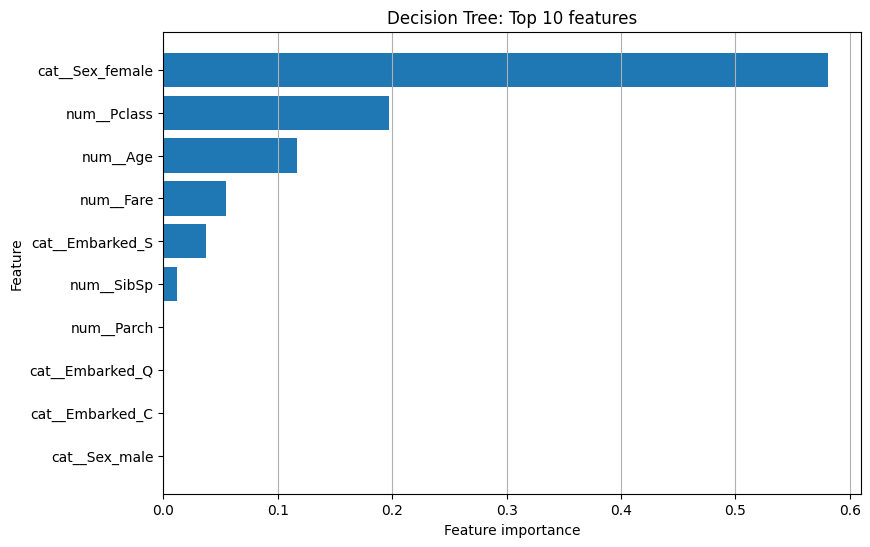

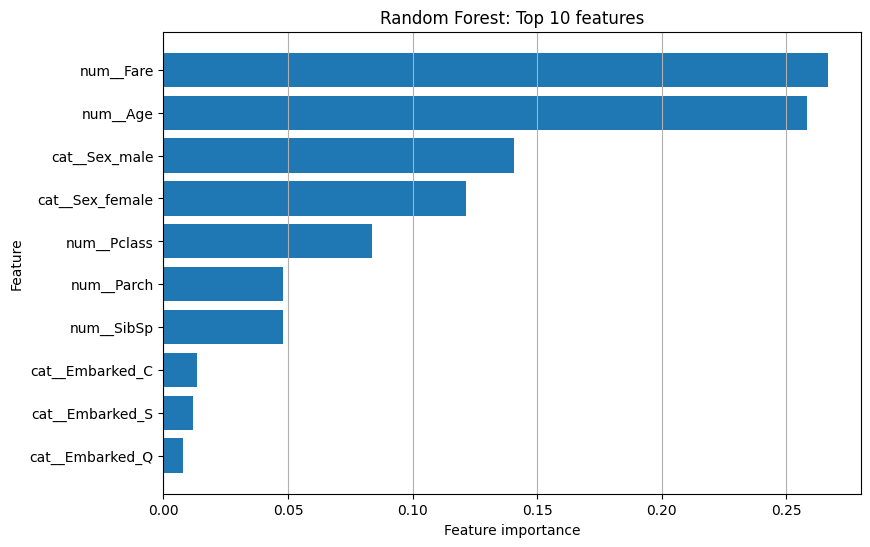

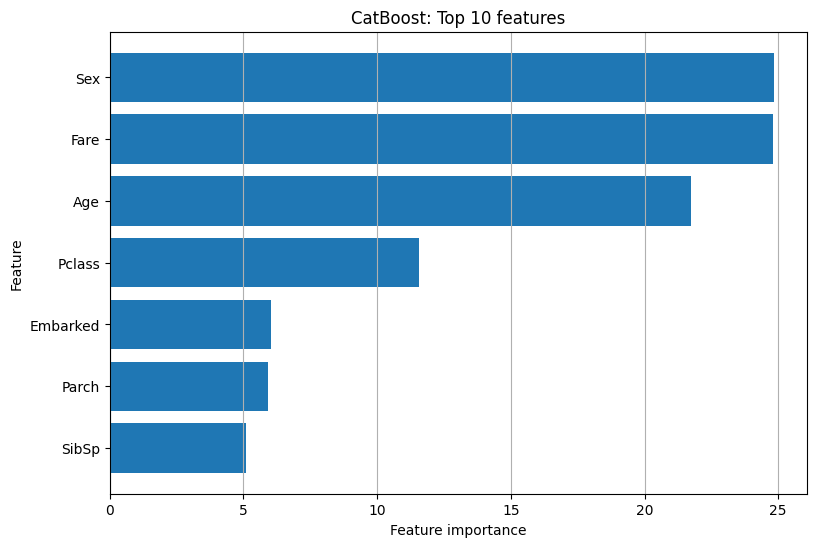

=== Decision Tree ===
        Feature  Importance
cat__Sex_female    0.580692
    num__Pclass    0.197414
       num__Age    0.116982
      num__Fare    0.054413
cat__Embarked_S    0.037482
     num__SibSp    0.012201
     num__Parch    0.000815
  cat__Sex_male    0.000000
cat__Embarked_C    0.000000
cat__Embarked_Q    0.000000

=== Random Forest ===
        Feature  Importance
      num__Fare    0.266586
       num__Age    0.258288
  cat__Sex_male    0.140753
cat__Sex_female    0.121420
    num__Pclass    0.083786
     num__Parch    0.048190
     num__SibSp    0.047860
cat__Embarked_C    0.013392
cat__Embarked_S    0.011786
cat__Embarked_Q    0.007940

=== CatBoost ===
 Feature  Importance
     Sex   24.845883
    Fare   24.811809
     Age   21.752567
  Pclass   11.560512
Embarked    6.014326
   Parch    5.920168
   SibSp    5.094734


In [27]:
# =========================
# ВАЖНОСТЬ ПРИЗНАКОВ
# =========================

# Decision Tree
tree_importance = pd.DataFrame({
    "Feature": tree.named_steps["prep"].get_feature_names_out(),
    "Importance": tree.named_steps["model"].feature_importances_
}).sort_values("Importance", ascending=False)


# Random Forest
rf_importance = pd.DataFrame({
    "Feature": rf_model.named_steps["preprocessor"].get_feature_names_out(),
    "Importance": rf_model.named_steps["model"].feature_importances_
}).sort_values("Importance", ascending=False)


# CatBoost
cat_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": cat_model.feature_importances_
}).sort_values("Importance", ascending=False)


# =========================
# Графики
# =========================

for name, importance_df in [
    ("Decision Tree", tree_importance),
    ("Random Forest", rf_importance),
    ("CatBoost", cat_importance)
]:

    top = importance_df.head(10).sort_values("Importance")

    plt.figure(figsize=(9, 6))

    plt.barh(
        top["Feature"],
        top["Importance"]
    )

    plt.xlabel("Feature importance")
    plt.ylabel("Feature")
    plt.title(f"{name}: Top 10 features")
    plt.grid(axis="x")

    plt.show()


# =========================
# Таблицы
# =========================

print("=== Decision Tree ===")
print(tree_importance.head(10).to_string(index=False))

print("\n=== Random Forest ===")
print(rf_importance.head(10).to_string(index=False))

print("\n=== CatBoost ===")
print(cat_importance.head(10).to_string(index=False))

* Во всех трёх моделях Sex, Fare, Age и Pclass входят в число наиболее важных признаков.
* Для Decision Tree наиболее значимым оказался `Sex` (58%), затем `Pclass` и `Age`.
* В Random Forest - `Fare` и `Age`, затем пол и класс. Что довольно странно, учитывая, что пол коррелирует сильнее всего.
* В CatBoost - `Sex`, `Fare` и `Age`.
* `Embarked`, `SibSp` и `Parch` в целом влияют слабее. Random Forest использует их заметнее всего
* В целом модели используют преимущественно пол, возраст, социальный класс и стоимость билета для предсказания выживаемости.

